In [1]:
using CovidSim_ilm

In [3]:
using StatsBase
using TypedTables
using BenchmarkTools
using Distributions
using YAML
using PrettyPrint
using Plots
using SplitApplyCombine

In [5]:
cd(joinpath(homedir(),"Dropbox/Covid Modeling/Covid-ILM/src"))

In [6]:
cs = CovidSim_ilm

CovidSim_ilm

In [8]:
vaxset = cs.build_vaxset("vaccines.yml")

Dict{Symbol, Vaccineparams} with 3 entries:
  :Moderna => Vaccineparams(2, 21, 280, Dict(:first=>Dict(:alpha=>0.92, :base=>…
  :Pfizer  => Vaccineparams(2, 21, 280, Dict(:first=>Dict(:alpha=>0.9, :base=>0…
  :JnJ     => Vaccineparams(1, 0, 240, Dict(:first=>Dict(:alpha=>0.88, :base=>0…

In [9]:
@btime $vaxset[:Pfizer]

  2.416 ns (0 allocations: 0 bytes)


Vaccineparams(2, 21, 280, Dict(:first => Dict(:alpha => 0.9, :base => 0.9, :delta => 0.84), :full => Dict(:alpha => 0.94, :base => 0.94, :delta => 0.88), :booster => Dict(:alpha => 0.94, :base => 0.94, :delta => 0.88)), 14, 0.5, 0.75)

In [10]:
pfizer = vaxset[:Pfizer]

Vaccineparams(2, 21, 280, Dict(:first => Dict(:alpha => 0.9, :base => 0.9, :delta => 0.84), :full => Dict(:alpha => 0.94, :base => 0.94, :delta => 0.88), :booster => Dict(:alpha => 0.94, :base => 0.94, :delta => 0.88)), 14, 0.5, 0.75)

In [11]:
@btime $pfizer;

  0.834 ns (0 allocations: 0 bytes)


In [12]:
pfizerparams = pfizer
pprint(pfizerparams)
@btime $pfizerparams.halflife

Vaccineparams(
  reqdshots=2,
  delay2ndshot=21,
  halflife=280,
  effectiveness={
                  :first : {:alpha : 0.9, 
                            :base : 0.9, 
                            :delta : 0.84},
                  :full : {:alpha : 0.94, 
                           :base : 0.94, 
                           :delta : 0.88},
                  :booster : {:alpha : 0.94, 
                              :base : 0.94, 
                              :delta : 0.88},
                },
  full_effect_days=14,
  day1_effect=0.5,
  infectfactor=0.75,
)  0.833 ns (0 allocations: 0 bytes)


280

In [13]:
# set locale and number of days
locale = 38015
ndays = 180

180

In [14]:
alldat = setup(ndays, [locale]; 
    dovax=true,
    paramdir="../parameters", 
    geofilename="../data/geo2data.csv",
    socialfilename = "socialparams.yml",
    vaccinefilename = "vaccines.yml",
    variantsfilename = "variants.yml"
    );

In [15]:
keys(alldat)

(:ndays, :locales, :dat, :transitionset, :geo, :vaxset, :vaxschedset, :infectset, :social, :trvec)

In [16]:
alldat.dat

Dict{String, Dict{Int64}} with 4 entries:
  "agegrp_idx" => Dict{Int64, Dict{agegrp, Vector{Int64}}}(38015=>Dict(age20_39…
  "newhistmx"  => Dict{Int64, Array{Int64}}(38015=>[0 0 … 0 0; 0 0 … 0 0; … ; 0…
  "popdat"     => Dict{Int64, Table{NamedTuple{(:pid, :status, :agegrp, :cond, …
  "cumhistmx"  => Dict{Int64, Array{Int64}}(38015=>[0 0 … 0 0; 0 0 … 0 0; … ; 0…

In [17]:
locdat = alldat.dat["popdat"][locale]

Table with 18 columns and 95626 rows:
      pid  status     agegrp   cond        duration  variant  recovday  ⋯
    ┌───────────────────────────────────────────────────────────────────
 1  │ 1    unexposed  age0_19  uninfected  0        [:none]  [0]       ⋯
 2  │ 2    unexposed  age0_19  uninfected  0        [:none]  [0]       ⋯
 3  │ 3    unexposed  age0_19  uninfected  0        [:none]  [0]       ⋯
 4  │ 4    unexposed  age0_19  uninfected  0        [:none]  [0]       ⋯
 5  │ 5    unexposed  age0_19  uninfected  0        [:none]  [0]       ⋯
 6  │ 6    unexposed  age0_19  uninfected  0        [:none]  [0]       ⋯
 7  │ 7    unexposed  age0_19  uninfected  0        [:none]  [0]       ⋯
 8  │ 8    unexposed  age0_19  uninfected  0        [:none]  [0]       ⋯
 9  │ 9    unexposed  age0_19  uninfected  0        [:none]  [0]       ⋯
 10 │ 10   unexposed  age0_19  uninfected  0        [:none]  [0]       ⋯
 11 │ 11   unexposed  age0_19  uninfected  0        [:none]  [0]       ⋯
 12 │ 12   u

In [18]:
locdat.vaxrcvd

95626-element Vector{Vector{Symbol}}:
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 ⋮
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]
 [:none]

In [19]:
ages = alldat.dat["agegrp_idx"][locale]

Dict{agegrp, Vector{Int64}} with 5 entries:
  age20_39 => [24003, 24004, 24005, 24006, 24007, 24008, 24009, 24010, 24011, 2…
  age0_19  => [1, 2, 3, 4, 5, 6, 7, 8, 9, 10  …  23993, 23994, 23995, 23996, 23…
  age40_59 => [49918, 49919, 49920, 49921, 49922, 49923, 49924, 49925, 49926, 4…
  age60_79 => [74303, 74304, 74305, 74306, 74307, 74308, 74309, 74310, 74311, 7…
  age80_up => [91898, 91899, 91900, 91901, 91902, 91903, 91904, 91905, 91906, 9…

In [20]:
columnnames(locdat)

(:pid, :status, :agegrp, :cond, :duration, :variant, :recovday, :deadday, :cluster, :sdcomply, :vaxstatus, :vaxrcvd, :vaxday, :fullvaxday, :tested, :testday, :quar, :quarday)

In [21]:
countmap(locdat.agegrp)

Dict{agegrp, Int64} with 5 entries:
  age20_39 => 25915
  age0_19  => 24002
  age40_59 => 24385
  age60_79 => 17595
  age80_up => 3729

In [22]:
countmap(locdat.status)  # everyone begins as unexposed

Dict{status, Int64} with 1 entry:
  unexposed => 95626

In [23]:
geodf = alldat.geo   # the date for all locales has been read into a dataframe

,fips,county,city,state,sizecat,pop,density,density_factor
,Int64,String15,String15,String3,Int64,Int64,Int64,Float64
1,6075,San Francisco,San Francisco,CA,2,881549,17255,1.04109
2,53033,Seattle,Seattle,WA,2,2252782,5175,0.931603
3,36061,New York,New York,NY,1,8336817,40306,1.25
4,39035,Cuyahoga,Cleveland,OH,2,1235072,3063,0.912462
5,48113,Dallas,Dallas,TX,2,2635516,4000,0.920954
6,39151,Stark,Canton,OH,3,370606,1688,0.9
7,34013,Essex,Newark,NJ,3,798975,6396,0.942669
8,13089,DeKalb,Atlanta,GA,2,1063937,2708,0.909244
9,17167,Sangamon,Springfield,IL,3,194672,1747,0.900535


In [24]:
density_factor = geodf[geodf[!, :fips] .== locale, :density_factor][]

0.9042506085245222

In [25]:
alldat.infectset[:base]  # the spread parameters are loaded as a dict of float arrays

Infectparams([0.0, 0.3, 0.65, 0.75, 0.85, 0.85, 0.75, 0.7, 0.65, 0.6  …  0.05, 0.05, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.1, 0.39, 0.44, 0.54, 0.56], 0.6, 180, 1.0)

In [26]:
alldat.social

CovidSim_ilm.Socialparams(1.0, Dict{Enum, Dict{Enum, Float64}}(age20_39 => Dict(mild => 2.0, sick => 1.0, nil => 2.1, severe => 0.6), age0_19 => Dict(mild => 1.1, sick => 0.7, nil => 1.1, severe => 0.5), age40_59 => Dict(mild => 2.0, sick => 1.0, nil => 2.1, severe => 0.6), age60_79 => Dict(mild => 1.6, sick => 0.7, nil => 1.7, severe => 0.5), age80_up => Dict(mild => 0.9, sick => 0.6, nil => 1.0, severe => 0.5)), Dict{Enum, Dict{Enum, Float64}}(age20_39 => Dict(mild => 0.62, sick => 0.35, recovered => 0.63, nil => 0.63, severe => 0.18, unexposed => 0.63), age0_19 => Dict(mild => 0.55, sick => 0.28, recovered => 0.55, nil => 0.55, severe => 0.18, unexposed => 0.55), age40_59 => Dict(mild => 0.58, sick => 0.3, recovered => 0.61, nil => 0.61, severe => 0.18, unexposed => 0.61), age60_79 => Dict(mild => 0.41, sick => 0.18, recovered => 0.41, nil => 0.41, severe => 0.18, unexposed => 0.41), age80_up => Dict(mild => 0.28, sick => 0.18, recovered => 0.35, nil => 0.35, severe => 0.18, unexpos

In [27]:
fieldnames(typeof(alldat.social))

(:gammashape, :contactfactors, :touchfactors)

In [28]:
contactfactors = alldat.social.contactfactors

Dict{Enum, Dict{Enum, Float64}} with 5 entries:
  age20_39 => Dict(mild=>2.0, sick=>1.0, nil=>2.1, severe=>0.6)
  age0_19  => Dict(mild=>1.1, sick=>0.7, nil=>1.1, severe=>0.5)
  age40_59 => Dict(mild=>2.0, sick=>1.0, nil=>2.1, severe=>0.6)
  age60_79 => Dict(mild=>1.6, sick=>0.7, nil=>1.7, severe=>0.5)
  age80_up => Dict(mild=>0.9, sick=>0.6, nil=>1.0, severe=>0.5)

In [29]:
typeof(contactfactors)

Dict{Enum, Dict{Enum, Float64}}

In [30]:
contactfactors[age80_up]

Dict{Enum, Float64} with 4 entries:
  mild   => 0.9
  sick   => 0.6
  nil    => 1.0
  severe => 0.5

In [31]:
touchfactors =  alldat.social.touchfactors

Dict{Enum, Dict{Enum, Float64}} with 5 entries:
  age20_39 => Dict(mild=>0.62, sick=>0.35, recovered=>0.63, nil=>0.63, severe=>…
  age0_19  => Dict(mild=>0.55, sick=>0.28, recovered=>0.55, nil=>0.55, severe=>…
  age40_59 => Dict(mild=>0.58, sick=>0.3, recovered=>0.61, nil=>0.61, severe=>0…
  age60_79 => Dict(mild=>0.41, sick=>0.18, recovered=>0.41, nil=>0.41, severe=>…
  age80_up => Dict(mild=>0.28, sick=>0.18, recovered=>0.35, nil=>0.35, severe=>…

In [32]:
touchfactors[age40_59]

Dict{Enum, Float64} with 6 entries:
  mild      => 0.58
  sick      => 0.3
  recovered => 0.61
  nil       => 0.61
  severe    => 0.18
  unexposed => 0.61

In [33]:
limdict = CovidSim_ilm.limdict
limdict(touchfactors, <)  # recursive minimum

0.18

In [34]:
alldat.vaxset

Dict{Symbol, Vaccineparams} with 3 entries:
  :Moderna => Vaccineparams(2, 21, 280, Dict(:first=>Dict(:alpha=>0.92, :base=>…
  :Pfizer  => Vaccineparams(2, 21, 280, Dict(:first=>Dict(:alpha=>0.9, :base=>0…
  :JnJ     => Vaccineparams(1, 0, 240, Dict(:first=>Dict(:alpha=>0.88, :base=>0…

In [35]:
typeof(alldat.vaxset)

Dict{Symbol, Vaccineparams}

In [36]:
pprintln(alldat.vaxset[:Pfizer])

Vaccineparams(
  reqdshots=2,
  delay2ndshot=21,
  halflife=280,
  effectiveness={
                  :first : {:alpha : 0.9, 
                            :base : 0.9, 
                            :delta : 0.84},
                  :full : {:alpha : 0.94, 
                           :base : 0.94, 
                           :delta : 0.88},
                  :booster : {:alpha : 0.94, 
                              :base : 0.94, 
                              :delta : 0.88},
                },
  full_effect_days=14,
  day1_effect=0.5,
  infectfactor=0.75,
)


In [37]:
# is shifter working?
shifter(touchfactors, (.18, .3)...)[age40_59]

Dict{Enum, Float64} with 6 entries:
  mild      => 0.286667
  sick      => 0.212
  recovered => 0.294667
  nil       => 0.294667
  severe    => 0.18
  unexposed => 0.294667

### Testing/checking decision trees (new type as transition matrices)

In [38]:
dectree = alldat.transitionset[:base] # the decision trees for all age groups are loaded

CovidSim_ilm.Transitionparams(CovidSim_ilm.Agetree(CovidSim_ilm.Transitiondef[CovidSim_ilm.Transitiondef(5, [0.0 0.4 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0]), CovidSim_ilm.Transitiondef(9, [0.9 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.05 0.0; 0.0 0.0 … 0.0 0.0]), CovidSim_ilm.Transitiondef(14, [1.0 0.0 … 0.0 0.0; 1.0 0.0 … 0.0 0.0; 0.85 0.0 … 0.03 0.0; 0.692 0.0 … 0.302 0.006]), CovidSim_ilm.Transitiondef(19, [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.891 0.0 … 0.106 0.003]), CovidSim_ilm.Transitiondef(25, [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.976 0.0 … 0.0 0.024; 0.91 0.0 … 0.0 0.09])], CovidSim_ilm.Transitiondef[CovidSim_ilm.Transitiondef(5, [0.0 0.2 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0]), CovidSim_ilm.Transitiondef(9, [0.9 0.0 … 0.0 0.0; 0.85 0.0 … 0.0 0.0; 0.0 0.0 … 0.1 0.0; 0.0 0.0 … 0.0 0.0]), CovidSim_ilm.Transitiondef(14, [1.0 0.0 … 0.0 0.0; 1.0 0.0 … 0.0 0.0; 0.83 0.0 … 0.07 0.0; 0.474 0.0 … 0.5

In [46]:
transarr = alldat.transitionset[:base].tree

CovidSim_ilm.Agetree(CovidSim_ilm.Transitiondef[CovidSim_ilm.Transitiondef(5, [0.0 0.4 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0]), CovidSim_ilm.Transitiondef(9, [0.9 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.05 0.0; 0.0 0.0 … 0.0 0.0]), CovidSim_ilm.Transitiondef(14, [1.0 0.0 … 0.0 0.0; 1.0 0.0 … 0.0 0.0; 0.85 0.0 … 0.03 0.0; 0.692 0.0 … 0.302 0.006]), CovidSim_ilm.Transitiondef(19, [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.891 0.0 … 0.106 0.003]), CovidSim_ilm.Transitiondef(25, [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.976 0.0 … 0.0 0.024; 0.91 0.0 … 0.0 0.09])], CovidSim_ilm.Transitiondef[CovidSim_ilm.Transitiondef(5, [0.0 0.2 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0]), CovidSim_ilm.Transitiondef(9, [0.9 0.0 … 0.0 0.0; 0.85 0.0 … 0.0 0.0; 0.0 0.0 … 0.1 0.0; 0.0 0.0 … 0.0 0.0]), CovidSim_ilm.Transitiondef(14, [1.0 0.0 … 0.0 0.0; 1.0 0.0 … 0.0 0.0; 0.83 0.0 … 0.07 0.0; 0.474 0.0 … 0.514 0.012]), CovidSim_ilm.Trans

In [40]:
# CovidSim_ilm.display_tree_array(transarr)

In [47]:
transarr.age0_19

5-element Vector{CovidSim_ilm.Transitiondef}:
 CovidSim_ilm.Transitiondef(5, [0.0 0.4 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0])
 CovidSim_ilm.Transitiondef(9, [0.9 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.05 0.0; 0.0 0.0 … 0.0 0.0])
 CovidSim_ilm.Transitiondef(14, [1.0 0.0 … 0.0 0.0; 1.0 0.0 … 0.0 0.0; 0.85 0.0 … 0.03 0.0; 0.692 0.0 … 0.302 0.006])
 CovidSim_ilm.Transitiondef(19, [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.891 0.0 … 0.106 0.003])
 CovidSim_ilm.Transitiondef(25, [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.976 0.0 … 0.0 0.024; 0.91 0.0 … 0.0 0.09])

In [49]:
# sequences = CovidSim_ilm.getseqs_struct(transarr.age0_19);

LoadError: MethodError: no method matching getindex(::CovidSim_ilm.Transitiondef, ::Symbol)

In [ ]:
CovidSim_ilm.verifyprobs(sequences)

UndefVarError: UndefVarError: sequences not defined

In [ ]:
CovidSim_ilm.sanitycheck_array(transarr)

UndefVarError: UndefVarError: sanitycheck_array not defined

In [ ]:
next_transition = [0.9 0.0 0.0 0.1 0.0 0.0; 0.0 0.0 1.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.95 0.05 0.0; 0.0 0.0 0.0 0.0 0.0 0.0]

4×6 Matrix{Float64}:
 0.9  0.0  0.0  0.1   0.0   0.0
 0.0  0.0  1.0  0.0   0.0   0.0
 0.0  0.0  0.0  0.95  0.05  0.0
 0.0  0.0  0.0  0.0   0.0   0.0

In [ ]:
next_steps = [ i for i in eachindex(next_transition[:,1]) if any(next_transition[i,:] .!= 0.0) ] 

3-element Vector{Int64}:
 1
 2
 3

In [ ]:
tr_age0_19 = transarr[age0_19]
T = typeof(tr_age0_19[1][:transition])
supertype(T)

MethodError: MethodError: no method matching getindex(::CovidSim_ilm.Transitionparams, ::agegrp)

In [ ]:
trvec = zeros(6)
p_cond = mild
p_duration = 9
trvec = CovidSim_ilm.has(tr_age0_19, p_duration, p_cond, trvec)
println(typeof(trvec))
trvec



UndefVarError: UndefVarError: tr_age0_19 not defined

In [ ]:
typeof(dectree)

CovidSim_ilm.Transitionparams

Dict{Int64, OrderedCollections.OrderedDict{Int, Dict{String, Vector{T} where T}

In [ ]:
dectree[age80_up]

MethodError: MethodError: no method matching getindex(::CovidSim_ilm.Transitionparams, ::agegrp)

In [ ]:
transitions = dectree[age80_up][5][:transition]

MethodError: MethodError: no method matching getindex(::CovidSim_ilm.Transitionparams, ::agegrp)

In [ ]:
breakdays = [dectree[age80_up][i][:duration] for i in sort(collect(keys(dectree[age80_up])))]

MethodError: MethodError: no method matching getindex(::CovidSim_ilm.Transitionparams, ::agegrp)

In [ ]:
next_steps = [i for i in eachindex(transitions[:,1]) if any(transitions[i,:] .!= 0.0)]  # if any(transitions[i,:] .!= 0.0) 

UndefVarError: UndefVarError: transitions not defined

In [ ]:
breakday = 5
findfirst(isequal(breakday), breakdays)

UndefVarError: UndefVarError: breakdays not defined

In [ ]:
findall(transitions[7,:] .!= 0.0)

UndefVarError: UndefVarError: transitions not defined

In [ ]:
collect(eachindex(transitions[5,:]))

UndefVarError: UndefVarError: transitions not defined

In [ ]:
typeof(dectree[age80_up][5][:transition])

MethodError: MethodError: no method matching getindex(::CovidSim_ilm.Transitionparams, ::agegrp)

In [ ]:
typeof(dectree[age80_up][5][:transition]) <: AbstractArray

MethodError: MethodError: no method matching getindex(::CovidSim_ilm.Transitionparams, ::agegrp)

In [ ]:
dectree[age80_up][1][:transition]

MethodError: MethodError: no method matching getindex(::CovidSim_ilm.Transitionparams, ::agegrp)

In [ ]:
typeof(dectree[age80_up][5][:transition])

MethodError: MethodError: no method matching getindex(::CovidSim_ilm.Transitionparams, ::agegrp)

# Create a seed case

In [5]:
seed_1_6 = seed_case_gen(1, [0,3,3,0,0], 1, nil, :base, agegrps)

(::CovidSim_ilm.var"#runcase#81"{CovidSim_ilm.var"#runcase#80#82"{Int64, Vector{Int64}, Int64, condition, Symbol, NTuple{5, agegrp}}}) (generic function with 1 method)

# Run a simulation

In [6]:
ndays = 180
locale = 38015

model = buildsim(ndays, locale;
            dovax=true);

In [10]:

popdat, series = runsim(model; 
    dovax=false, 
    dovariant=false,
    showr0=false, 
    silent=true, 
    runcases=[seed_1_6]);

*** seed day 1: 6 nil to 38015
(idxtime, vaxtime, sprtime, trtime, histtime) = (0.09417025999999998, 0, 0.8198512089999999, 0.13850944800000006, 0.6371660940000003)


In [8]:
model.infectset

OrderedCollections.LittleDict{Symbol, Infectparams, Vector{Symbol}, Vector{Infectparams}} with 4 entries:
  :base    => Infectparams([0.0, 0.3, 0.65, 0.75, 0.85, 0.85, 0.75, 0.7, 0.65, …
  :alpha   => Infectparams(Float64[], Float64[], 0.6, 240, 1.2)
  :delta   => Infectparams(Float64[], Float64[], 0.6, 240, 1.2)
  :omicron => Infectparams(Float64[], Float64[], 0.6, 240, 1.2)

In [ ]:
@btime $model.infectset[:base].sendrisk[7]

In [ ]:
locdat = popdat[locale]

In [ ]:
countmap(locdat.status)

In [ ]:
countmap(locdat.status)

In [ ]:
virus_outcome(series, locale, base=:pop)

In [ ]:
series[locale][:cum]

# Plot results

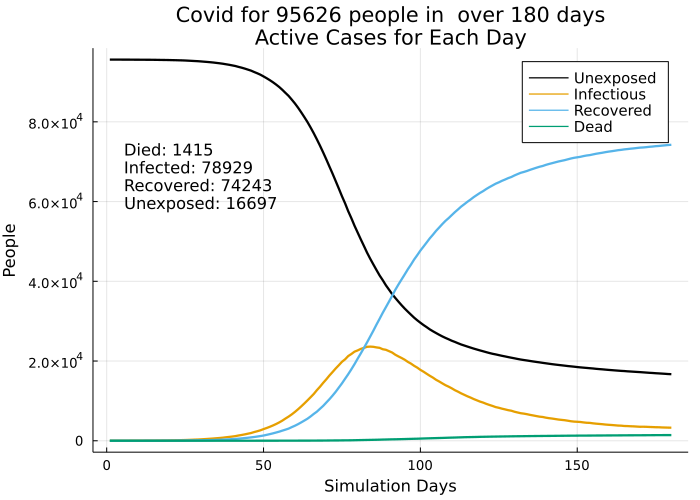

In [11]:
cumplot(series, locale)

Note that the orangle line labeled Infectious that shows the number of infected people is *not* what you see in newspaper accounts. In this plot Infectious shows the net infected people: Some people got sick today. Some people get better: they're not infectious any more--they recovered and are on the blue line. Sadly, some people died--they're not infectious either--they're dead and are on the green line. Newspaper tracking shows the new active infections of each day--who got sick today? The next day, if no one new got sick the line would be at zero--even though the people who got sick aren't better yet. So, the newspaper line goes up and down faster. Yet another approach is to show the cumulative number of infected people: This keeps going up until no one new gets infected--then the line is high but levels off. This is the least common way to show the data.

## Run simulation with full vaccination schedule

In [ ]:
seed_1_6 = seed_case_gen(1, [0,3,3,0,0], 1, nil, :base, agegrps)

In [ ]:
ndays = 280
locale = 38015

model = buildsim(ndays, locale;
            dovax=true);

In [ ]:

popdat, series = runsim(model; 
    dovax=true, 
    dovariant=false,
    showr0=false, 
    silent=true, 
    runcases=[seed_1_6]);

In [ ]:
cumplot(series, locale)

In [ ]:
locdat = popdat[locale]
vaxcols = @Select(vaxrcvd, vaxstatus)(locdat)

In [ ]:
map2series

In [ ]:
series[38015][:cum][:, map2series[:Pfizer]] 

In [ ]:
pfizer2shots = sum(map(v -> (first(v) == :Pfizer) & (length(v) == 2) ? 2 
            : 0, vaxcols.vaxrcvd))
pfizer1shots = sum(map(v -> (first(v) == :Pfizer) & (length(v) == 1) ? 1 
            : 0, vaxcols.vaxrcvd))

peoplepfizer2 = sum(map(v -> (first(v) == :Pfizer) & (length(v) == 2) ? 1 
            : 0, vaxcols.vaxrcvd))
peoplepfizer1 = sum(map(v -> (first(v) == :Pfizer) & (length(v) == 1) ? 1 
            : 0, vaxcols.vaxrcvd))

moderna2shots = sum(map(v -> (first(v) == :Moderna) & (length(v) == 2) ? 2 
            : 0, vaxcols.vaxrcvd))
moderna1shots = sum(map(v -> (first(v) == :Moderna) & (length(v) == 1) ? 1 
            : 0, vaxcols.vaxrcvd))

peoplemoderna2 = sum(map(v -> (first(v) == :Moderna) & (length(v) == 2) ? 1 
            : 0, vaxcols.vaxrcvd))
peoplemoderna1 = sum(map(v -> (first(v) == :Moderna) & (length(v) == 1) ? 1 
            : 0, vaxcols.vaxrcvd))

peoplejnj = jnjshots = sum(map(v -> (first(v) == :JnJ) & (length(v) == 1) ? 1 
            : 0, vaxcols.vaxrcvd))

peopleatleast1shot = (peoplepfizer2 + peoplepfizer1 + peoplemoderna2 + peoplemoderna1 +
                    peoplejnj)

peoplefull = count(vaxcols.vaxstatus .== :full) 

@show pfizer2shots, pfizer1shots
@show peoplepfizer2, peoplepfizer1

@show moderna2shots, moderna1shots
@show peoplemoderna2, peoplemoderna1

@show jnjshots

@show peopleatleast1shot, peoplefull

In [ ]:
count(vaxcols.vaxstatus .== :full)

In [ ]:
count(vaxcols.vaxstatus .== :first)

## Test a social distancing case

In [ ]:
sd1 = sd_gen(startday = 55, comply=0.9, cf=(.2,1.0), tf=(.18,.6), name=:mod_80, include_ages=[])    

In [ ]:
sd1_end = sd_gen(startday = 90, comply=0.0, cf=(.2,1.5), tf=(.18,.6), name=:mod_80, include_ages=[])

In [ ]:
popdat, series = runsim(model, showr0=false, silent=true, runcases=[seed_1_6, sd1, sd1_end]);

In [ ]:
virus_outcome(series, locale, base=:pop)

In [ ]:
cumplot(series, locale)

In [ ]:
cumplot(series, locale,[:infectious, :dead])

In [ ]:
outdat = popdat[locale]
all(outdat.sdcomply .== :none)

## Social distancing only among those age40_59, age60_79, age80_plus

In [ ]:
sdolder = sd_gen(startday = 55, comply=0.9, cf=(.2,1.0), tf=(.18,.6), name=:mod_80, 
    include_ages=[age40_59, age60_79, age80_up])    

In [ ]:
sdolder_end = sd_gen(startday = 90, comply=0.0, cf=(.2,1.5), tf=(.18,.6), name=:mod_80, 
    include_ages=[age40_59, age60_79, age80_up])    

In [ ]:
popdat, series = runsim(model, showr0=false, silent=true, 
    runcases=[seed_1_6, sdolder, sdolder_end]);

In [ ]:
olderdat = popdat[locale]

sd = findall(olderdat.sdcomply .!= :none)

@Select(agegrp, sdcomply)(olderdat[sd])

In [ ]:
cumplot(series, locale)

In [ ]:
cumplot(series, locale, [:infectious, :dead])

## Social Distancing starts with everyone and then the younger folks party

In [ ]:
sdyoung_end = sd_gen(startday = 90, comply=0.0, cf=(.2,1.5), tf=(.18,.6), name=:mod_80, 
    include_ages=[age0_19, age20_39])    

In [ ]:
popdat, series = runsim(model; showr0=false, silent=true, 
    runcases=[seed_1_6, sd1, sdyoung_end]);

In [ ]:
mixdat = popdat[locale]

sd = findall(mixdat.sdcomply .!= :none)
young = findall((mixdat.agegrp .== age0_19) .| (mixdat.agegrp .== age20_39))
sd_young_idx = intersect(sd, young)
old = findall((mixdat.agegrp .== age40_59) .| (mixdat.agegrp .== age60_79) .| (mixdat.agegrp .== age80_up));

In [ ]:
youngtab = Table(mixdat[young])
count(youngtab.sdcomply .== :none)

In [ ]:
oldtab = Table(mixdat[old])
count(oldtab.sdcomply .!= :none)

In [ ]:
typeof(mixdat.agegrp)

In [ ]:
mixdat = popdat[locale]

In [ ]:
cumplot(series, locale, [:infectious, :dead])

In [ ]:
@Select(status, agegrp, cond, sdcomply)(locdat)

In [ ]:
ages = alldat.dat["agegrp_idx"][locale]

In [ ]:
include_ages = [age0_19, age20_39]

In [ ]:
union((ages[i] for i in include_ages)...)

In [ ]:
locdat.sdcomply[collect(1:5:95000)] .= :test

In [ ]:
incase_idx = findall(locdat.sdcomply .== :test)

In [ ]:
byage_idx = intersect(incase_idx, union((ages[i] for i in include_ages)...))

In [ ]:
@btime locdat.status;

In [ ]:
statuscol = locdat.status
@btime statuscol;

In [ ]:
nt = (one=1, two=2, three=3)

In [ ]:
@btime nt.one;

In [ ]:
thisone = nt.one
@btime thisone;

## Creating filter and seed

In [ ]:
colfetch = :agegrp
op = ==

In [ ]:
filtdict = Dict(:agegrp => [age0_19, age80_up],
                :status => [unexposed],)
filtcmp = Dict(:agegrp => ==, 
                :variant => ==, 
                :cond => ==, 
                :status => ==,
                :sd_comply => ==)

In [ ]:
@btime andor = .&(  
              .|( .==(locdat.agegrp, age0_19), .==(locdat.agegrp, age80_up) ), 
              .|( .==(locdat.status, unexposed), .==(locdat.status, infectious) )
           );

In [ ]:
andor = .&(  
              .|( .==(locdat.agegrp, age0_19), .==(locdat.agegrp, age80_up) ), 
              .|( .==(locdat.status, unexposed), .==(locdat.status, infectious) )
           );
count(andor)

In [ ]:
count(reduce(.|,map(x -> .==(locdat.agegrp, x), filtdict[:agegrp])))

In [ ]:
infilt = [ :agegrp => [age80_up, age0_19], :status => [unexposed, infectious]]

In [ ]:
colage = getproperty(locdat, :agegrp)
colstatus = getproperty(locdat, :status)
@btime ((colage .== age0_19) .| (colage .== age80_up)) .& ((colstatus .== unexposed) .| (colstatus .== infectious));

In [ ]:
@btime reduce(.&, map(y -> reduce(.|, Iterators.map(x -> getproperty($locdat, y.first) .== x, y.second)), $infilt));

In [ ]:
e = :(10 + 10)

In [ ]:
eval(e)

In [ ]:
@eval $e

In [ ]:
holder = [BitVector(rand(Bool, 5)), BitVector(rand(Bool, 5))]

In [ ]:
typeof(locdat.agegrp .== age0_19)

In [ ]:
function dofilt_mapreduce(dat, filts)
    # println(filts)
    res = trues(size(dat,1));
    for filt in filts
        comparevals = filt[2]
        col = filt[1]
        res[:] .&= mapreduce(y -> .==(getproperty(dat, col), y), .|, comparevals)
    end
    return res
end

In [ ]:
function dofilt_loop(dat, filts)
    # println(filts)
    res = trues(size(dat,1));
    for filt in filts
        comparevals = filt[2]
        col = filt[1]
        for cval in comparevals
            getproperty(dat, col) .== cval
        end
        res[:] .&= mapreduce(y -> .==(getproperty(dat, col), y), .|, comparevals)
    end
    return res
end

In [ ]:
finalfilt = dofilt_loop(locdat, infilt);
count(finalfilt)

In [ ]:
finalfilt = dofilt_mapreduce(locdat, infilt);
count(finalfilt)

In [ ]:
@btime dofilt_mapreduce(locdat, infilt);

In [ ]:
@btime dofilt_loop(locdat, infilt);

In [ ]:
@btime foo = ((locdat.agegrp .== age0_19) .| (locdat.agegrp .== age80_up)) .& ((locdat.status .== unexposed) .| (locdat.status .== infectious));

In [ ]:
@btime locdat.status;

In [ ]:
@btime getproperty(locdat, :status);

## Using Split Apply Combine

In [ ]:
?group

In [ ]:
selcols = Table(agegrp = locdat.agegrp, status = locdat.status)

In [ ]:
by2colidx = groupinds(selcols)

In [ ]:
locdat[by2colidx[(agegrp=age0_19, status=recovered)]]

In [ ]:
typeof(locdat)

In [ ]:
Popdat = typeof(locdat)

In [ ]:
function getter(dat::Popdat, prop::Symbol, p)
    getproperty(dat, prop)[p]
end

In [ ]:
@btime getter(locdat, :status, 1);

In [ ]:
@btime locdat.status[1];

In [ ]:
col_status = locdat.status;

In [ ]:
@btime col_status[1];

In [ ]:
const a,b,c,d = 1,2,3,4

In [ ]:
foobar = [[1,2,3,4],[10,11,12,13]]

In [ ]:
@enum Colnums begin
    c1 = 1
    c2
    c3
    c4
end

In [ ]:
@btime foobar[Int(c1)][2];

In [ ]:
foobar1 = hcat(foobar...)

In [ ]:
@btime foobar1[1,1];

In [ ]:
@btime foobar[1][2];

In [ ]:
col1 = foobar[Int(c1)]

In [ ]:
@btime col1[2];

In [ ]:
foobar

In [ ]:
foobar[2]

In [ ]:
eltype(foobar)

In [ ]:
tt = Vector{Vector{T}} where T

In [ ]:
function row(arr::Vector{Vector{T}} where {T}, i::Int64)
    res = Array{Any}(undef, length(arr))
    for c in eachindex(arr)
        @inbounds res[c] = @inbounds arr[c][i]
    end
    res
end

function row2(arr::Vector{Vector{T}} where {T}, i::Int64)
    # [r[i] for r in arr]
    map(r -> @inbounds(r[i]), arr)
end

function row3(arr, i)
    res = eltype(arr)(undef, length(arr))
    n = 1
    for j in arr
        @inbounds res[n] = @inbounds(j[i]) 
        n += 1
    end
    return res
end

function row4(arr::Vector{Vector{T}} where {T}, i::Int64)
    [@inbounds(r[i]) for r in arr]
    # map(r -> @inbounds(getindex(r, i)), arr)
end

function row5(arr::Vector{Vector{T}} where {T}, i::Int64)
    # [r[i] for r in arr]
    map(n -> @inbounds(arr[n][i]), 1:size(arr,1))
end

In [ ]:
row5(foobar, 2)

In [ ]:
eltype(eltype(foobar))

In [ ]:
@btime row(foobar, 2)

In [ ]:
@btime row2(foobar, 2)

In [ ]:
@btime row3(foobar,2);

In [ ]:
@btime row4(foobar,2);

In [ ]:
@btime row5(foobar,2);

In [ ]:
tt = Table(a=foobar[1], b=foobar[2])

In [ ]:
@btime tt.a;

In [ ]:
@btime foobar[Int(c1)];

In [ ]:
@benchmark foobar[Int(c1)][2] = iv setup=(iv=44)

In [ ]:
@benchmark tt.a[2] = iv setup=(iv=44)

In [ ]:
@btime row2(foobar,2);

In [ ]:
@btime tt[2]

In [ ]:
Base.summarysize(tt)

In [ ]:
Base.summarysize(foobar)

In [ ]:
coltta = tt.a;

In [ ]:
colonefoo = foobar[Int(c1)];

In [ ]:
@btime coltta[2];

In [ ]:
@btime colonefoo[2];

In [ ]:
keys(getfield(locdat,:data))

In [ ]:
getfield(locdat, :data)